#**Stock_Price_Prediction_Using_LSTM_PyTorch**

In [1]:
#importing neccesary libraries
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns
import matplotlib.pyplot as plt

####**Initializing GPU Accelerator**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
#loading the google stock price data
df = pd.read_csv('/content/drive/MyDrive/Google_Stock_Price.csv', parse_dates=['date'])
df

,symbol,date,open,high,low,close,volume,adjclose,dividends,splits
0,GOOG,2018-01-02,52.417000,53.347000,52.261501,53.250000,24752000,53.059353,0.0,0.0
1,GOOG,2018-01-03,53.215500,54.314499,53.160500,54.124001,28604000,53.930225,0.0,0.0
2,GOOG,2018-01-04,54.400002,54.678501,54.200100,54.320000,20092000,54.125519,0.0,0.0
3,GOOG,2018-01-05,54.700001,55.212502,54.599998,55.111500,25582000,54.914188,0.0,0.0
4,GOOG,2018-01-08,55.111500,55.563499,55.081001,55.347000,20952000,55.148846,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1756,GOOG,2024-12-24,196.169998,197.669998,195.197998,197.570007,6809800,197.570007,0.0,0.0
1757,GOOG,2024-12-26,196.740005,198.160004,195.869995,197.100006,7907900,197.100006,0.0,0.0
1758,GOOG,2024-12-27,196.470001,196.800003,191.972000,194.039993,14693000,194.039993,0.0,0.0
1759,GOOG,2024-12-30,190.865005,193.779999,190.360001,192.690002,12209500,192.690002,0.0,0.0


##**Exploratory Data Analysis & Pre Processing**

In [4]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'adjclose',
       'dividends', 'splits'],
      dtype='object')

In [5]:
df.drop('symbol', axis=1, inplace=True)
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'adjclose',
       'dividends', 'splits'],
      dtype='object')

In [6]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1761 non-null   datetime64[ns]
 1   open       1761 non-null   float64       
 2   high       1761 non-null   float64       
 3   low        1761 non-null   float64       
 4   close      1761 non-null   float64       
 5   volume     1761 non-null   int64         
 6   adjclose   1761 non-null   float64       
 7   dividends  1761 non-null   float64       
 8   splits     1761 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 123.9 KB


In [7]:
print("\nStatistical summary:")
df.describe()


Statistical summary:


,date,open,high,low,close,volume,adjclose,dividends,splits
count,1761,1761.000000,1761.000000,1761.000000,1761.000000,1.761000e+03,1761.000000,1761.000000,1761.000000
mean,2021-07-01 15:36:17.172061440,102.021411,103.171589,100.982265,102.092157,2.859376e+07,101.754831,0.000341,0.011357
min,2018-01-02 00:00:00,48.695000,50.176998,48.505501,48.811001,6.809800e+06,48.636250,0.000000,0.000000
25%,2019-10-02 00:00:00,61.463001,62.043999,60.938499,61.496498,1.992200e+07,61.276325,0.000000,0.000000
50%,2021-07-01 00:00:00,100.059998,101.658997,99.169998,100.739998,2.561200e+07,100.379326,0.000000,0.000000
75%,2023-03-31 00:00:00,135.570007,137.070999,134.183502,135.990005,3.304600e+07,135.503128,0.000000,0.000000
max,2024-12-31 00:00:00,198.529999,202.880005,196.690002,198.160004,1.241400e+08,198.160004,0.200000,20.000000
std,NaN,39.637483,40.020994,39.274690,39.637305,1.317064e+07,39.547744,0.008250,0.476596


In [8]:
print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


,0
date,0
open,0
high,0
low,0
close,0
volume,0
adjclose,0
dividends,0
splits,0


##**Line plot of the closing price over time**

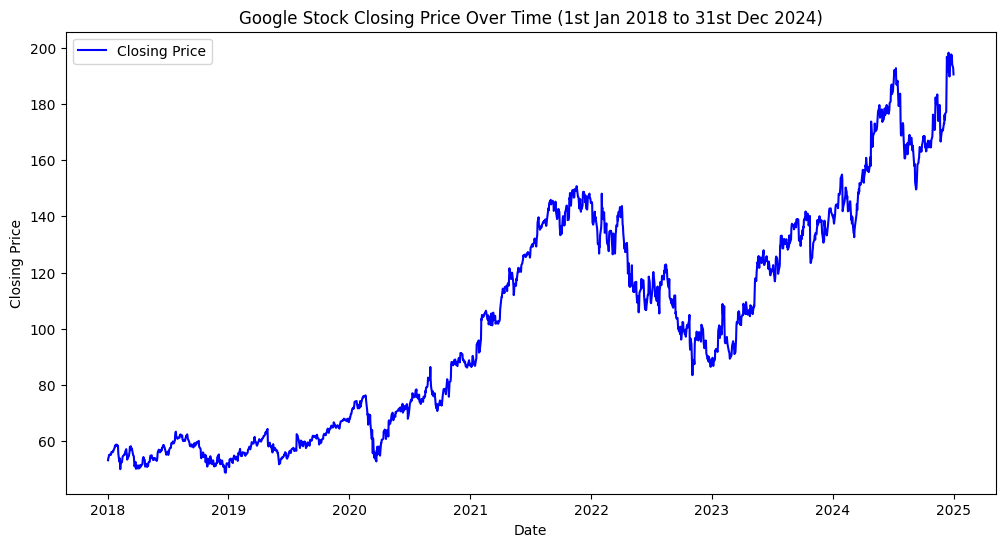

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df['close'], label='Closing Price', color='blue')
plt.title('Google Stock Closing Price Over Time (1st Jan 2018 to 31st Dec 2024)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

##**Correlation heatmap to show relationships between features**

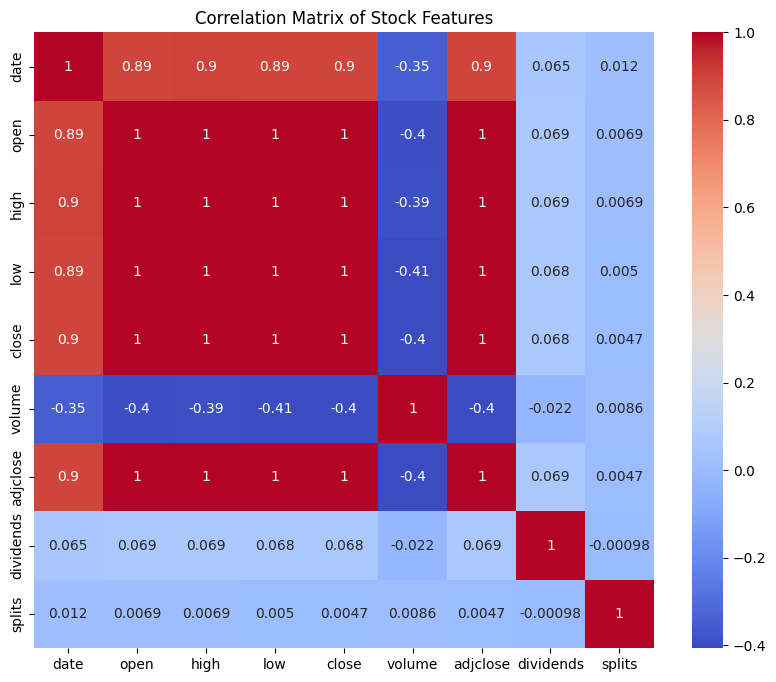

In [10]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Stock Features')
plt.show()

##**Scatter plot to examine the relationship between Close Price and Volume**

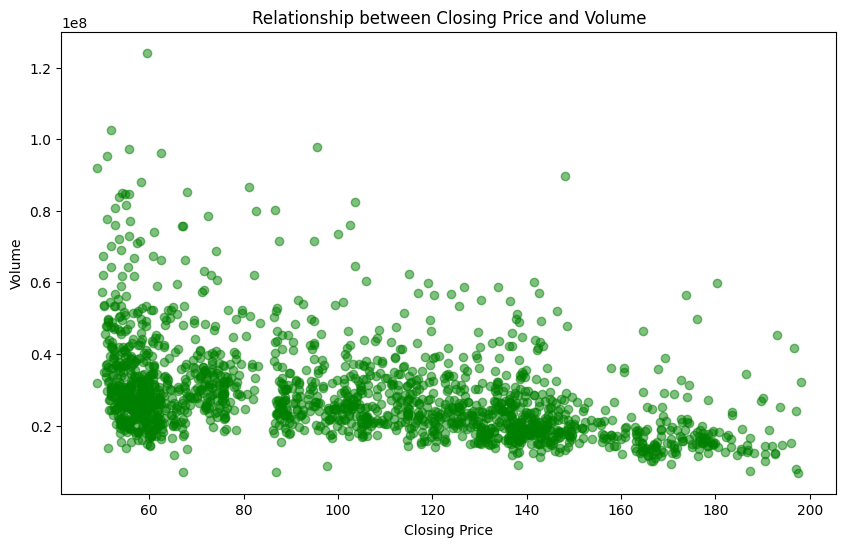

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df['close'], df['volume'], alpha=0.5, color='green')
plt.title('Relationship between Closing Price and Volume')
plt.xlabel('Closing Price')
plt.ylabel('Volume')
plt.show()

#****

In [27]:
## input-output sequences
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

#this means the model will use previous 60 days of stock prices to predict the next day prices
seq_length = 60
close_data = df[['close']].values
X, y = create_sequences(close_data, seq_length)


In [28]:
# Split into training and testing sets (80% train, 20% test)
train_size = int(len(X) * 0.8)

#This performs a chronological split,which is correct for time series data
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [29]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1360, 60, 1)
Shape of X_test: (341, 60, 1)
Shape of y_train: (1360, 1)
Shape of y_test: (341, 1)


In [30]:
X_train[:1]

array([[[53.25      ],
        [54.12400055],
        [54.31999969],
        [55.11149979],
        [55.34700012],
        [55.31299973],
        [55.13050079],
        [55.27600098],
        [56.11299896],
        [56.08800125],
        [56.59899902],
        [56.48949814],
        [56.87549973],
        [57.79050064],
        [58.49850082],
        [58.2120018 ],
        [58.51850128],
        [58.79199982],
        [58.77899933],
        [58.18450165],
        [58.49700165],
        [58.38499832],
        [55.59500122],
        [52.79000092],
        [54.02999878],
        [52.42900085],
        [50.07600021],
        [51.88899994],
        [52.59700012],
        [52.60499954],
        [53.48500061],
        [54.47600174],
        [54.74000168],
        [55.1230011 ],
        [55.56700134],
        [55.33150101],
        [56.33950043],
        [57.1875    ],
        [55.91450119],
        [55.23649979],
        [53.47600174],
        [53.94599915],
        [54.54650116],
        [54

In [31]:
y_train[:1]

array([[51.58950043]])

In [32]:
# Normalizing the train and test data
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Scale target values
y_train_scaled = scaler.transform(y_train.reshape(-1, 1))

y_test_scaled = scaler.transform(y_test.reshape(-1, 1))


In [33]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train_scaled.shape)
print(y_test_scaled.shape)

(1360, 60, 1)
(341, 60, 1)
(1360, 1)
(341, 1)


In [34]:
X_train_scaled[:1]

array([[[0.04356316],
        [0.05214037],
        [0.05406386],
        [0.06183143],
        [0.06414257],
        [0.0638089 ],
        [0.0620179 ],
        [0.0634458 ],
        [0.07165988],
        [0.07141456],
        [0.07642935],
        [0.07535474],
        [0.07914286],
        [0.08812244],
        [0.09507056],
        [0.09225894],
        [0.09526684],
        [0.09795088],
        [0.0978233 ],
        [0.09198906],
        [0.09505585],
        [0.09395668],
        [0.06657638],
        [0.03904885],
        [0.05121787],
        [0.0355061 ],
        [0.01241437],
        [0.03020667],
        [0.0371548 ],
        [0.0372333 ],
        [0.0458694 ],
        [0.05559482],
        [0.05818565],
        [0.0619443 ],
        [0.0663016 ],
        [0.06399046],
        [0.0738827 ],
        [0.08220475],
        [0.06971187],
        [0.06305815],
        [0.04578108],
        [0.05039351],
        [0.05628668],
        [0.05831319],
        [0.06546741],
        [0

In [35]:
y_train_scaled[:1]

array([[0.02726746]])

In [36]:
#tranforming from np arrays to tensors
X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()
y_train_tensor = torch.from_numpy(y_train_scaled).float()
y_test_tensor = torch.from_numpy(y_test_scaled).float()

In [37]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)
print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([1360, 60, 1])
torch.Size([341, 60, 1])
torch.Size([1360, 1])
torch.Size([341, 1])


In [38]:
#train loader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

In [39]:
len(train_loader)

22

In [41]:
for X_batch, y_batch in train_loader:
    print("Shape of X_batch:", X_batch.shape)
    print("Shape of y_batch:", y_batch.shape)
    break

Shape of X_batch: torch.Size([64, 60, 1])
Shape of y_batch: torch.Size([64, 1])


##**Simple LSTM Model: 1 LSTM layer + small hidden size(50)**

In [42]:
#Architecture of LSTM Model
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch_size, seq_length, input_size)
        out, _ = self.lstm(x)
        # Only take the output from the last time step
        out = self.fc(out[:, -1, :])
        return out

##**Medium LSTM Model: 2 LSTM layers + larger hidden size(100) + with dropout Layer(0.2)**

In [43]:
class MediumLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, num_layers=2, dropout=0.2):
        super(MediumLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

##**Complex LSTM Model: 3 LSTM layers + even larger hidden size(150) + with higher dropout(0.3)**

In [44]:
class ComplexLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=150, num_layers=3, dropout=0.3):
        super(ComplexLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

##**Training Function**

In [45]:
def train_model(model, train_loader, num_epochs, learning_rate):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()

    for epoch in range(num_epochs):
        epoch_losses = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {np.mean(epoch_losses):.6f}")
    return model

##**Training with Simple LSTM Model**

In [48]:
simple_model = SimpleLSTM()
print("Training Simple LSTM Model")
simple_model = train_model(simple_model, train_loader, num_epochs=100,learning_rate=0.001)

Training Simple LSTM Model
Epoch [1/100], Loss: 0.195698
Epoch [2/100], Loss: 0.049107
Epoch [3/100], Loss: 0.107305
Epoch [4/100], Loss: 0.029948
Epoch [5/100], Loss: 0.037560
Epoch [6/100], Loss: 0.017586
Epoch [7/100], Loss: 0.020519
Epoch [8/100], Loss: 0.012854
Epoch [9/100], Loss: 0.001898
Epoch [10/100], Loss: 0.002093
Epoch [11/100], Loss: 0.001971
Epoch [12/100], Loss: 0.001514
Epoch [13/100], Loss: 0.001319
Epoch [14/100], Loss: 0.001240
Epoch [15/100], Loss: 0.001160
Epoch [16/100], Loss: 0.001134
Epoch [17/100], Loss: 0.001156
Epoch [18/100], Loss: 0.001204
Epoch [19/100], Loss: 0.001279
Epoch [20/100], Loss: 0.001380
Epoch [21/100], Loss: 0.001506
Epoch [22/100], Loss: 0.001652
Epoch [23/100], Loss: 0.001815
Epoch [24/100], Loss: 0.001981
Epoch [25/100], Loss: 0.002133
Epoch [26/100], Loss: 0.002250
Epoch [27/100], Loss: 0.002313
Epoch [28/100], Loss: 0.002312
Epoch [29/100], Loss: 0.002252
Epoch [30/100], Loss: 0.002153
Epoch [31/100], Loss: 0.002039
Epoch [32/100], Loss:

##**Training with Medium LSTM Model**

In [49]:
medium_model = MediumLSTM()
print("\nTraining Medium LSTM Model")
medium_model = train_model(medium_model, train_loader, num_epochs=100,learning_rate=0.001)


Training Medium LSTM Model
Epoch [1/100], Loss: 0.068101
Epoch [2/100], Loss: 0.162952
Epoch [3/100], Loss: 0.054013
Epoch [4/100], Loss: 0.081021
Epoch [5/100], Loss: 0.030059
Epoch [6/100], Loss: 0.020613
Epoch [7/100], Loss: 0.002503
Epoch [8/100], Loss: 0.005146
Epoch [9/100], Loss: 0.001618
Epoch [10/100], Loss: 0.001245
Epoch [11/100], Loss: 0.001449
Epoch [12/100], Loss: 0.001273
Epoch [13/100], Loss: 0.001334
Epoch [14/100], Loss: 0.001402
Epoch [15/100], Loss: 0.001525
Epoch [16/100], Loss: 0.001465
Epoch [17/100], Loss: 0.001455
Epoch [18/100], Loss: 0.001372
Epoch [19/100], Loss: 0.001524
Epoch [20/100], Loss: 0.001682
Epoch [21/100], Loss: 0.001679
Epoch [22/100], Loss: 0.001818
Epoch [23/100], Loss: 0.001921
Epoch [24/100], Loss: 0.002372
Epoch [25/100], Loss: 0.003155
Epoch [26/100], Loss: 0.004524
Epoch [27/100], Loss: 0.006356
Epoch [28/100], Loss: 0.008633
Epoch [29/100], Loss: 0.009726
Epoch [30/100], Loss: 0.006489
Epoch [31/100], Loss: 0.003397
Epoch [32/100], Loss

##**Training with Complex LSTM Model**

In [50]:
complex_model = ComplexLSTM()
print("\nTraining Complex LSTM Model")
complex_model = train_model(complex_model, train_loader, num_epochs=100,learning_rate=0.001)


Training Complex LSTM Model
Epoch [1/100], Loss: 0.036454
Epoch [2/100], Loss: 0.134484
Epoch [3/100], Loss: 0.144320
Epoch [4/100], Loss: 0.087783
Epoch [5/100], Loss: 0.035456
Epoch [6/100], Loss: 0.008854
Epoch [7/100], Loss: 0.004561
Epoch [8/100], Loss: 0.005980
Epoch [9/100], Loss: 0.012807
Epoch [10/100], Loss: 0.015358
Epoch [11/100], Loss: 0.015312
Epoch [12/100], Loss: 0.009586
Epoch [13/100], Loss: 0.005602
Epoch [14/100], Loss: 0.004321
Epoch [15/100], Loss: 0.004055
Epoch [16/100], Loss: 0.003371
Epoch [17/100], Loss: 0.003840
Epoch [18/100], Loss: 0.004712
Epoch [19/100], Loss: 0.005113
Epoch [20/100], Loss: 0.005658
Epoch [21/100], Loss: 0.007260
Epoch [22/100], Loss: 0.008974
Epoch [23/100], Loss: 0.010479
Epoch [24/100], Loss: 0.009461
Epoch [25/100], Loss: 0.007832
Epoch [26/100], Loss: 0.005346
Epoch [27/100], Loss: 0.003710
Epoch [28/100], Loss: 0.002365
Epoch [29/100], Loss: 0.001997
Epoch [30/100], Loss: 0.001837
Epoch [31/100], Loss: 0.001767
Epoch [32/100], Los

##**Make Predictions on Test Data**

In [51]:
def predict(model, X_data):
    model.eval()
    with torch.no_grad():
        predictions = model(X_data).detach().cpu().numpy()
    return predictions

X_test_tensor = X_test_tensor.to(device)

pred_simple = predict(simple_model, X_test_tensor)
pred_medium = predict(medium_model, X_test_tensor)
pred_complex = predict(complex_model, X_test_tensor)

y_test_inv = scaler.inverse_transform(y_test_tensor)
pred_simple_inv = scaler.inverse_transform(pred_simple)
pred_medium_inv = scaler.inverse_transform(pred_medium)
pred_complex_inv = scaler.inverse_transform(pred_complex)

test_dates = df['date'].values[seq_length+train_size:]

##**Plotting the Results**

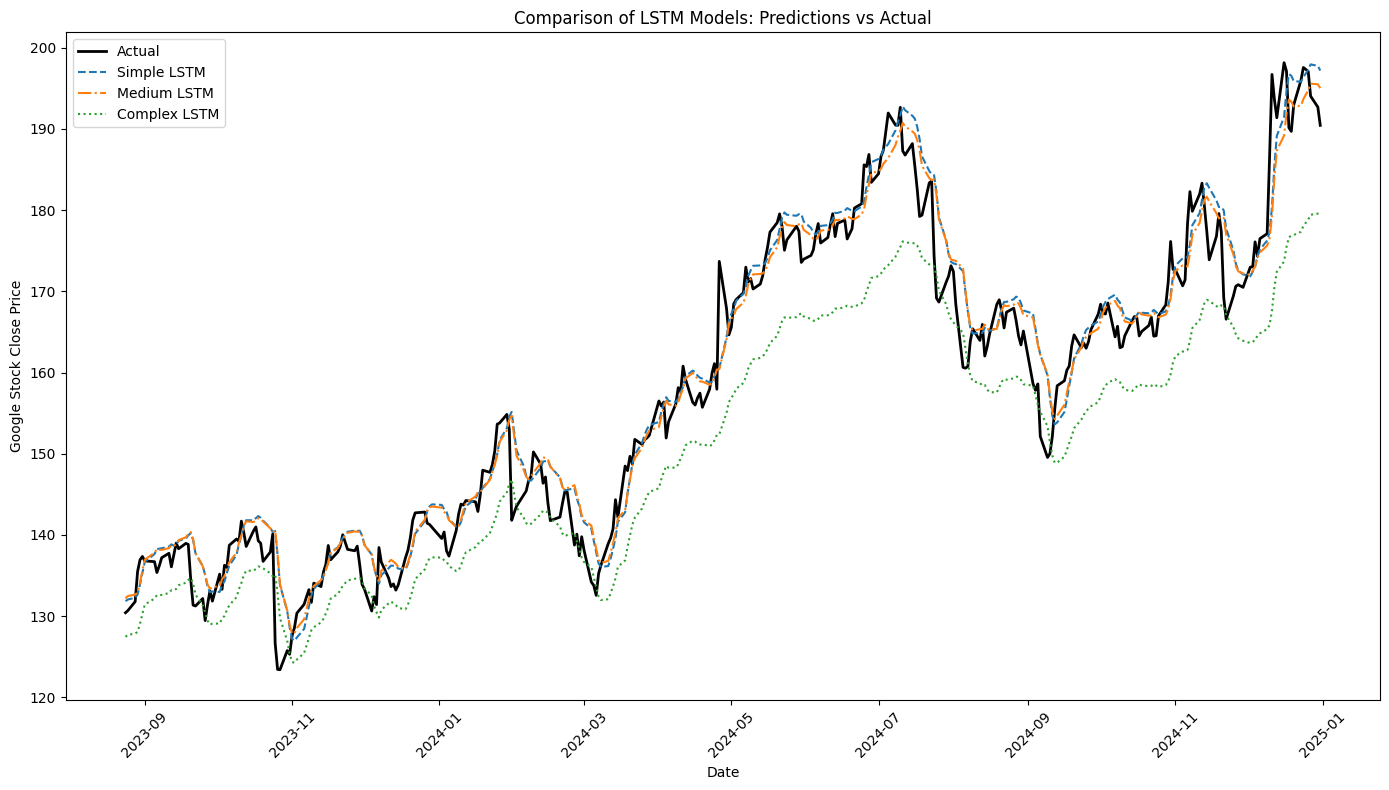

In [52]:
plt.figure(figsize=(14, 8))

plt.plot(test_dates, y_test_inv, label='Actual', color='black', linewidth=2)
plt.plot(test_dates, pred_simple_inv, label='Simple LSTM', linestyle='--')
plt.plot(test_dates, pred_medium_inv, label='Medium LSTM', linestyle='-.')
plt.plot(test_dates, pred_complex_inv, label='Complex LSTM', linestyle=':')
plt.title("Comparison of LSTM Models: Predictions vs Actual")
plt.xlabel("Date")
plt.ylabel("Google Stock Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**Individual plots for each Model**

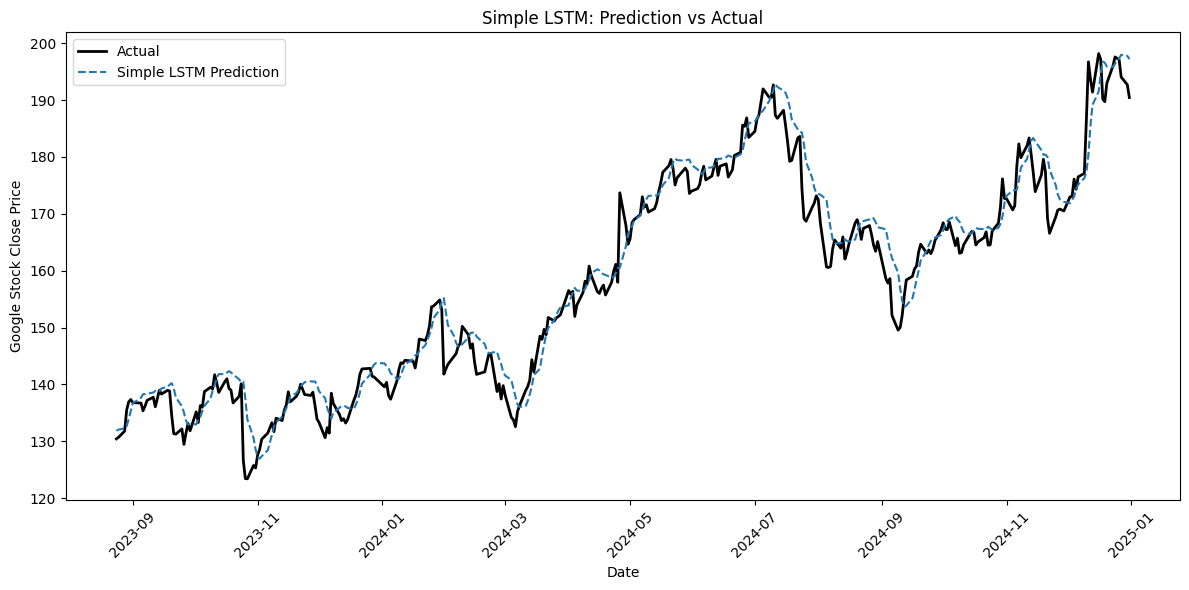

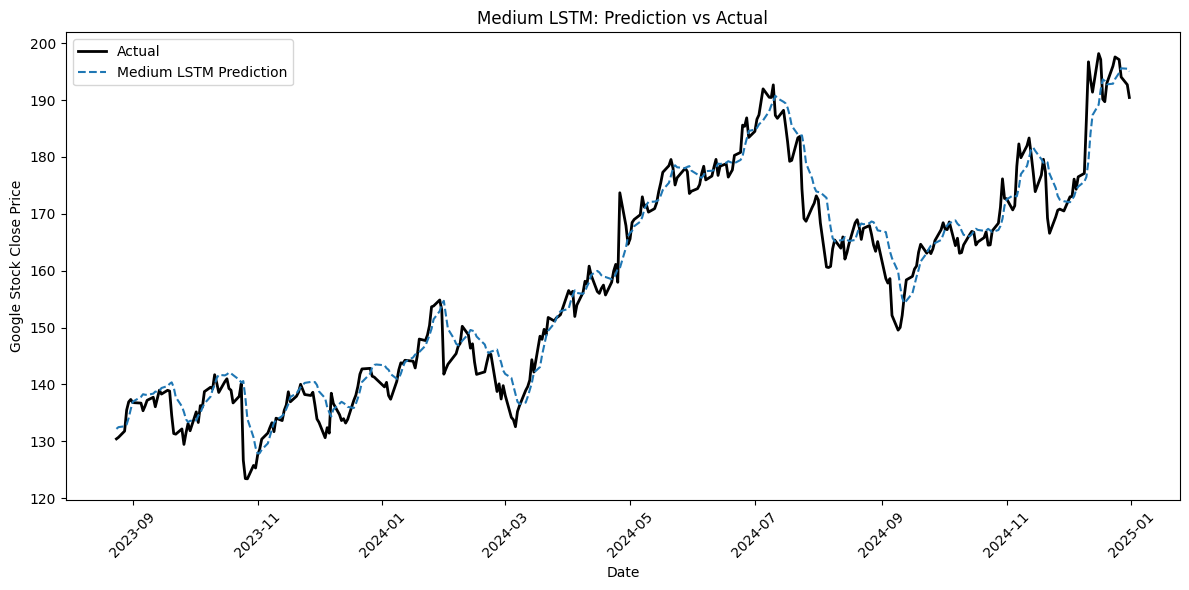

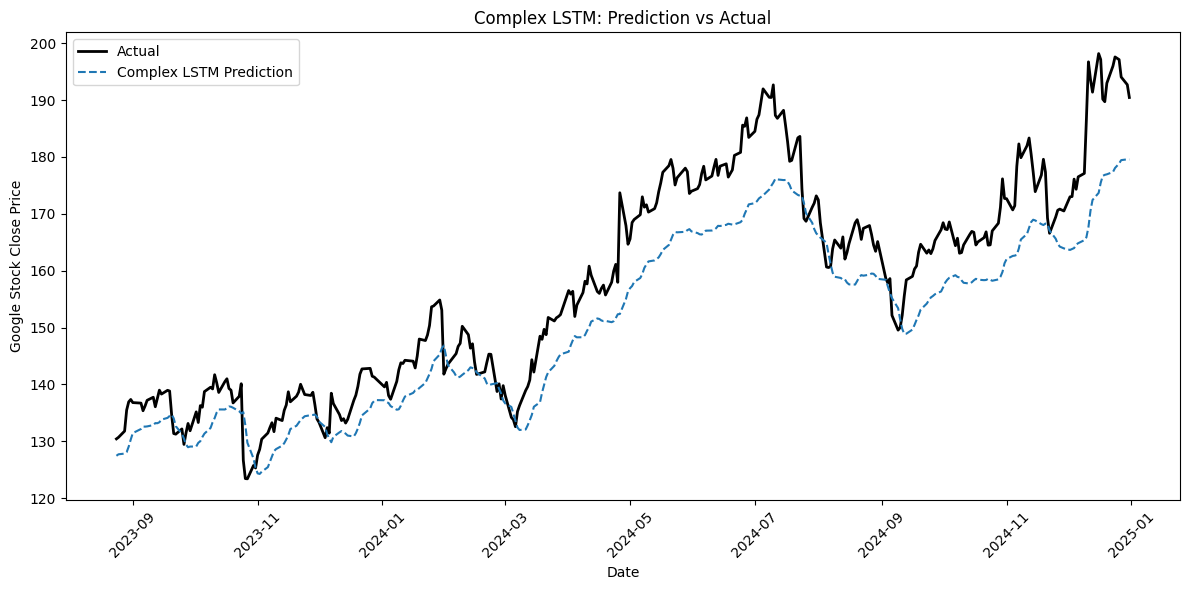

In [53]:
models = [('Simple LSTM', pred_simple_inv),
          ('Medium LSTM', pred_medium_inv),
          ('Complex LSTM', pred_complex_inv)]

for name, pred in models:
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_inv, label='Actual', color='black', linewidth=2)
    plt.plot(test_dates, pred, label=f'{name} Prediction', linestyle='--')
    plt.title(f"{name}: Prediction vs Actual")
    plt.xlabel("Date")
    plt.ylabel("Google Stock Close Price")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#**Conclusion**


The Simple Model is more efficient than the other Two Models

##**Forecasting the  Google stock price for Next 10 days**

In [54]:
last_sequence = close_data[-seq_length:]
last_sequence_tensor = torch.from_numpy(last_sequence).float().unsqueeze(0)

def forecast_future(model, init_seq, forecast_days=10):
    """
    Forecast the next forecast_days values using a trained LSTM model.
    Args:
        model: trained PyTorch model.
        init_seq: tensor of shape (1, seq_length, 1) used as the initial input.
        forecast_days: number of days to forecast.
    Returns:
        A numpy array of forecasted normalized values.
    """
    model.eval()
    predictions = []
    current_seq = init_seq.clone().to(device)

    with torch.no_grad():
        for _ in range(forecast_days):
            pred = model(current_seq)
            predictions.append(pred.item())
            pred_tensor = pred.view(1, 1, 1)
            current_seq = torch.cat((current_seq[:, 1:, :], pred_tensor), dim=1)

    return np.array(predictions)

forecast_days = 10

forecast_simple = forecast_future(simple_model, last_sequence_tensor, forecast_days)
forecast_medium = forecast_future(medium_model, last_sequence_tensor, forecast_days)
forecast_complex = forecast_future(complex_model, last_sequence_tensor, forecast_days)

forecast_simple_inv = scaler.inverse_transform(forecast_simple.reshape(-1, 1))
forecast_medium_inv = scaler.inverse_transform(forecast_medium.reshape(-1, 1))
forecast_complex_inv = scaler.inverse_transform(forecast_complex.reshape(-1, 1))

last_date = pd.to_datetime(df['date'].iloc[-1])
forecast_dates = pd.bdate_range(last_date + pd.Timedelta(days=1), periods=forecast_days)

##**Plotting the Forecast for next 10 days**

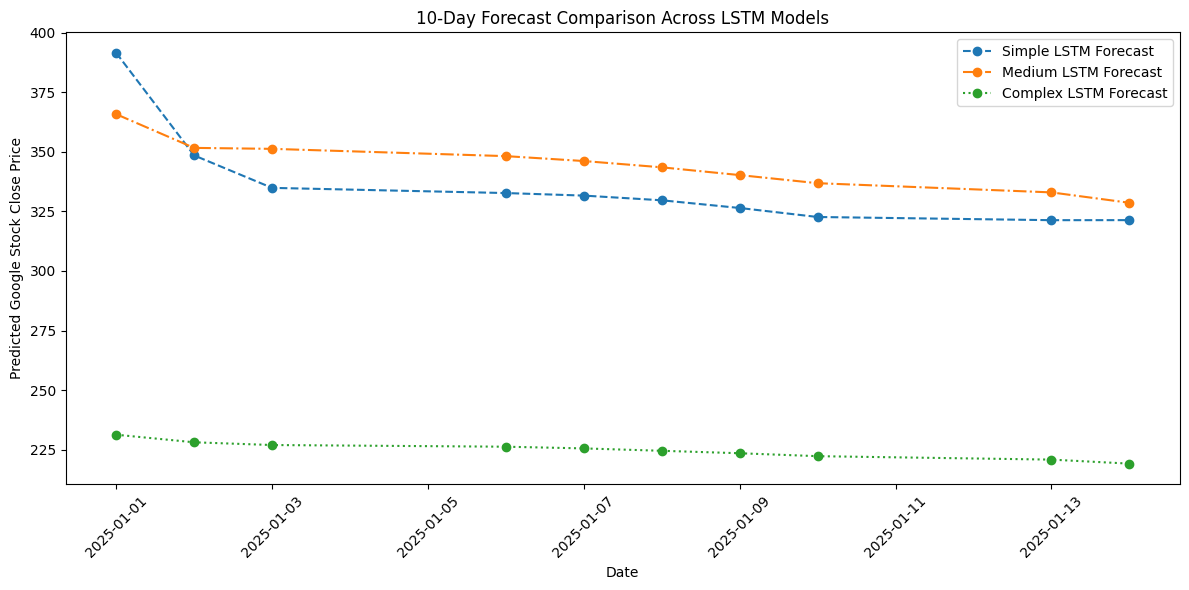

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(forecast_dates, forecast_simple_inv, marker='o', linestyle='--', label='Simple LSTM Forecast')
plt.plot(forecast_dates, forecast_medium_inv, marker='o', linestyle='-.', label='Medium LSTM Forecast')
plt.plot(forecast_dates, forecast_complex_inv, marker='o', linestyle=':', label='Complex LSTM Forecast')
plt.title("10-Day Forecast Comparison Across LSTM Models")
plt.xlabel("Date")
plt.ylabel("Predicted Google Stock Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##**Tabulation of Forecast Values**



In [57]:
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Simple LSTM': forecast_simple_inv.flatten(),
    'Medium LSTM': forecast_medium_inv.flatten(),
    'Complex LSTM': forecast_complex_inv.flatten()
})
print("Forecasted values for the next 10 days:")
print(forecast_df)

Forecasted values for the next 10 days:
        Date  Simple LSTM  Medium LSTM  Complex LSTM
0 2025-01-01   391.492796   365.764760    231.278006
1 2025-01-02   348.472072   351.625166    228.098650
2 2025-01-03   334.850385   351.221467    226.950497
3 2025-01-06   332.676452   348.167566    226.244746
4 2025-01-07   331.609151   346.111193    225.532362
5 2025-01-08   329.638853   343.472532    224.534908
6 2025-01-09   326.411612   340.213563    223.503247
7 2025-01-10   322.630047   336.813225    222.275239
8 2025-01-13   321.294342   332.953310    220.830659
9 2025-01-14   321.310814   328.596114    219.146160
